In [3]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix, brier_score_loss,
)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier

train = pd.read_csv("data/processed/train_features.csv")
test = pd.read_csv("data/processed/test_features.csv")

X_train, y_train = train.drop(columns=['target']), train['target']
X_test, y_test = test.drop(columns=['target']), test['target']

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train default rate: {y_train.mean():.2%} | Test default rate: {y_test.mean():.2%}")

Train: (1076280, 132), Test: (269070, 132)
Train default rate: 19.96% | Test default rate: 19.97%


# Baseline: Logistic Regression

In [4]:
logreg = LogisticRegression(
    class_weight='balanced', max_iter=2000, random_state=42,
)
logreg.fit(X_train, y_train)

logreg_proba = logreg.predict_proba(X_test)[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test, logreg_proba):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, logreg_proba):.4f}")

ROC-AUC: 0.7191
PR-AUC:  0.3848


# XGBoost

In [5]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
)
xgb.fit(X_train, y_train)

xgb_proba = xgb.predict_proba(X_test)[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, xgb_proba):.4f}")

scale_pos_weight: 4.01
ROC-AUC: 0.7293
PR-AUC: 0.4032


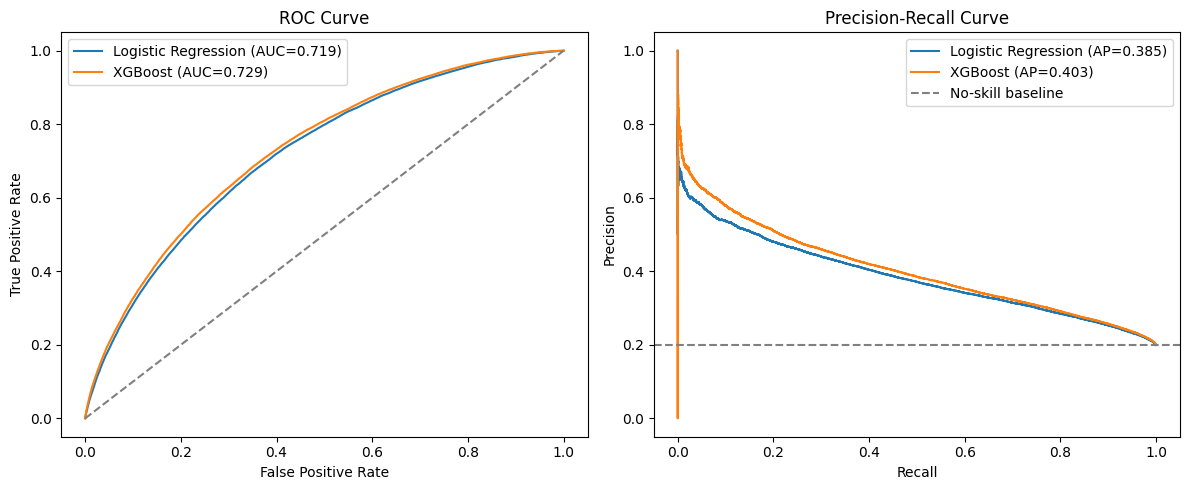

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, proba in [('Logistic Regression', logreg_proba), ('XGBoost', xgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")

    precision, recall, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(recall, precision, label=f"{name} (AP={average_precision_score(y_test, proba):.3f})")

axes[0].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC Curve')
axes[0].legend()

axes[1].axhline(y_test.mean(), linestyle='--', color='grey', label='No-skill baseline')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

# Calibration

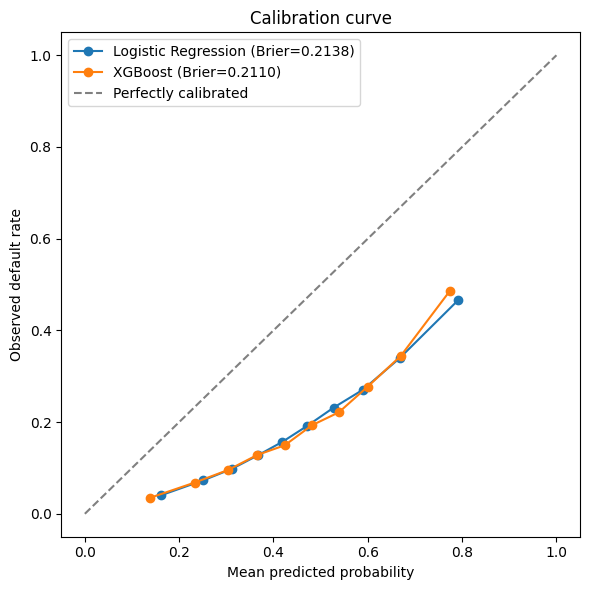

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

for name, proba in [('Logistic Regression', logreg_proba), ('XGBoost', xgb_proba)]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=f"{name} (Brier={brier_score_loss(y_test, proba):.4f})")

ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Perfectly calibrated')
ax.set(xlabel='Mean predicted probability', ylabel='Observed default rate', title='Calibration curve')
ax.legend()
plt.tight_layout()
plt.show()

# Threshold Analysis

In [8]:
def threshold_report(y_true, proba, thresholds=np.arange(0.1, 0.9, 0.05)):
    rows = []
    for t in thresholds:
        preds = (proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        precision = tp / (tp + fp) if (tp + fp) else 0
        recall = tp / (tp + fn) if (tp + fn) else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
        rows.append({
            'threshold': round(t, 2), 'precision': round(precision, 3),
            'recall': round(recall, 3), 'f1': round(f1, 3),
            'flagged_rate': round(preds.mean(), 3),
        })
    return pd.DataFrame(rows)

best_model_proba = xgb_proba 
report = threshold_report(y_test, best_model_proba)
report

,threshold,precision,recall,f1,flagged_rate
0,0.10,0.203,0.999,0.338,0.982
1,0.15,0.210,0.993,0.347,0.942
2,0.20,0.220,0.980,0.359,0.890
3,0.25,0.231,0.960,0.373,0.829
4,0.30,0.245,0.929,0.388,0.756
5,0.35,0.262,0.887,0.405,0.675
6,0.40,0.281,0.831,0.419,0.591
7,0.45,0.303,0.766,0.434,0.505
8,0.50,0.327,0.684,0.443,0.417
9,0.55,0.356,0.589,0.444,0.330


In [9]:
best_row = report.loc[report['f1'].idxmax()]
print(f"F1-optimal threshold: {best_row['threshold']} "
      f"(precision={best_row['precision']}, recall={best_row['recall']})")

CHOSEN_THRESHOLD = best_row['threshold']

F1-optimal threshold: 0.55 (precision=0.356, recall=0.589)


In [10]:
final_preds = (best_model_proba >= CHOSEN_THRESHOLD).astype(int)
print(classification_report(y_test, final_preds, target_names=['Fully Paid', 'Charged Off']))

cm = confusion_matrix(y_test, final_preds)
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(cm)

              precision    recall  f1-score   support

  Fully Paid       0.88      0.73      0.80    215350
 Charged Off       0.36      0.59      0.44     53720

    accuracy                           0.71    269070
   macro avg       0.62      0.66      0.62    269070
weighted avg       0.77      0.71      0.73    269070

Confusion matrix [[TN, FP], [FN, TP]]:
[[158137  57213]
 [ 22066  31654]]


In [11]:
import os
os.makedirs("src/models/artifacts", exist_ok=True)

joblib.dump(xgb, "src/models/artifacts/pd_model_xgb.joblib")
joblib.dump(logreg, "src/models/artifacts/pd_model_logreg.joblib")
joblib.dump(CHOSEN_THRESHOLD, "src/models/artifacts/decision_threshold.joblib")

['src/models/artifacts/decision_threshold.joblib']